
===== MÉTRICAS DA REDE =====
Número de nós: 36692
Número de arestas: 367662
Grau médio: 20.0404
Grau máximo: 2766
Densidade: 0.00027309755503535


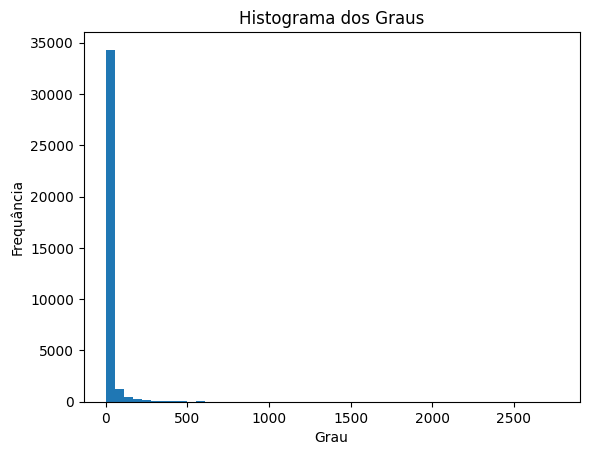

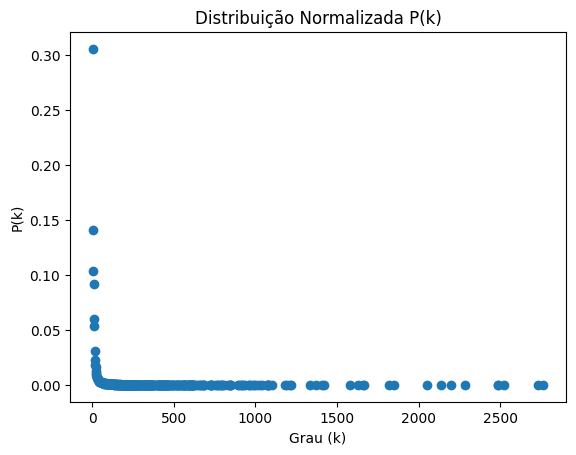


===== AJUSTE POWER LAW ====
Gamma: 1.5448560711268162
Constante C: 0.8071501337642143
R2: 0.892507036501637


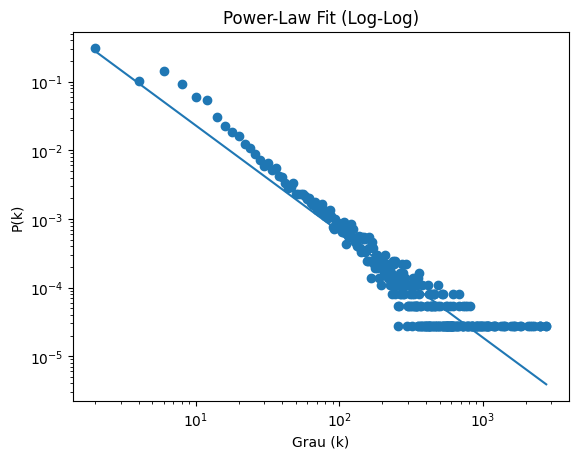

In [1]:
import matplotlib.pyplot as plt
import math
from collections import Counter


class Graph:

    def __init__(self, v):
        self.V = v
        self.E = 0
        self.adj = {}
        for v in range(self.V):
            self.adj[v] = Bag()

    def __str__(self):
        s = "%d vertices, %d edges\n" % (self.V, self.E)
        s += "\n".join("%d: %s" % (v, " ".join(str(w)
                                               for w in self.adj[v])) for v in range(self.V))
        return s

    def add_edge(self, v, w):
        v, w = int(v), int(w)
        self.adj[v].add(w)
        self.adj[w].add(v)
        self.E += 1

    def degree(self, v):
        return self.adj[v].size()   # ← era len(self.adj[v])

    def degrees(self):
        """Returns a list with the degree of every vertex."""
        return [self.degree(v) for v in range(self.V)]

    def max_degree(self):
        max_deg = 0
        for v in range(self.V):
            max_deg = max(max_deg, self.degree(v))
        return max_deg

    def avg_degree(self):
        return sum(self.degrees()) / self.V

    def degree_distribution(self):
        """
        Power-law fit on the degree distribution P(k) ~ C * k^slope.

        Returns a dict with:
          unique_deg, pk, log_x, log_y,
          slope, log_C, C,
          ss_res, ss_tot, r2
        """
        degs = self.degrees()
        freq  = Counter(degs)
        total = len(degs)

        unique_deg = sorted(freq)
        pk         = [freq[d] / total for d in unique_deg]

        # log10 – skip zero-degree vertices to avoid log(0)
        log_x = [math.log10(d) for d in unique_deg if d > 0]
        log_y = [math.log10(p) for p in pk         if p > 0]

        # ── Linear regression on log-log  (equivalent to np.polyfit degree=1) ──
        n      = len(log_x)
        sum_x  = sum(log_x)
        sum_y  = sum(log_y)
        sum_xy = sum(x * y for x, y in zip(log_x, log_y))
        sum_x2 = sum(x ** 2 for x in log_x)

        denom  = n * sum_x2 - sum_x ** 2
        slope  = (n * sum_xy - sum_x * sum_y) / denom
        log_C  = (sum_y - slope * sum_x) / n     # intercept

        # ── R² ──────────────────────────────────────────────────────────
        y_pred = [slope * x + log_C for x in log_x]
        ss_res = sum((y - yp) ** 2 for y, yp in zip(log_y, y_pred))
        mean_y = sum_y / n
        ss_tot = sum((y - mean_y) ** 2 for y in log_y)
        r2     = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')

        return {
            'unique_deg': unique_deg,
            'pk':         pk,
            'log_x':      log_x,
            'log_y':      log_y,
            'slope':      slope,
            'log_C':      log_C,
            'C':          10 ** log_C,
            'ss_res':     ss_res,
            'ss_tot':     ss_tot,
            'r2':         r2,
        }

    # ──────────────────────────────────────────

    def number_of_self_loops(self):
        count = 0
        for v in range(self.V):
            for w in self.adj[v]:
                if w == v:
                    count += 1
        return count


def read_graph(file_path):
    edges = []
    max_v = -1

    with open(file_path, 'r') as file:
        for line in file:
            line = line.strip()

            if not line or line.startswith('#'):
                continue

            parts = line.split()
            if len(parts) >= 2:
                try:
                    v = int(parts[0])
                    w = int(parts[1])
                    edges.append((v, w))

                    if v > max_v: max_v = v
                    if w > max_v: max_v = w
                except ValueError:
                    continue

    if max_v == -1:
        return None


    G = Graph(max_v + 1)


    for v, w in edges:
        G.add_edge(v, w)

    return G
class Bag:

    def __init__(self):
        self.first = None
        self.n = 0

    def __str__(self):
        return " ".join(str(i) for i in self)

    def __iter__(self):
        return LinkIterator(self.first)

    def size(self):
        return self.n

    def is_empty(self):
        return self.first is None

    def add(self, item):
        oldfirst = self.first
        self.first = Node(item, oldfirst)
        self.n += 1

class Node:

    def __init__(self, item, next_node):
        self.item = item
        self.next = next_node


class LinkIterator:

    def __init__(self, current):
        self.current = current

    def __next__(self):
        if self.current is None:
            raise StopIteration()
        else:
            item = self.current.item
            self.current = self.current.next
            return item

def main():

    file_path = "Email-Enron.txt"

    G = read_graph(file_path)

    num_nodes = G.V
    num_edges = G.E

    degrees   = G.degrees()
    max_degree = G.max_degree()
    avg_degree = G.avg_degree()

    density = num_edges / (num_nodes * (num_nodes - 1))

    print("\n===== MÉTRICAS DA REDE =====")
    print("Número de nós:", num_nodes)
    print("Número de arestas:", num_edges)
    print("Grau médio:", round(avg_degree, 4))
    print("Grau máximo:", max_degree)
    print("Densidade:", density)

    # ── Histograma ───────────────────────────────────────────
    plt.figure()
    plt.hist(degrees, bins=50)
    plt.title("Histograma dos Graus")
    plt.xlabel("Grau")
    plt.ylabel("Frequância")
    plt.show()

    # ── Distribuição P(k)
    freq       = Counter(degrees)
    total      = len(degrees)
    unique_deg = sorted(freq)
    pk         = [freq[d] / total for d in unique_deg]

    plt.figure()
    plt.scatter(unique_deg, pk)
    plt.title("Distribuição Normalizada P(k)")
    plt.xlabel("Grau (k)")
    plt.ylabel("P(k)")
    plt.show()

    # ── Power-law fit — substitui np.log10, np.polyfit, np.sum, np.mean ─────
    # Filtra k=0 e p=0 para evitar log(0)
    pairs = [(d, p) for d, p in zip(unique_deg, pk) if d > 0 and p > 0]
    log_x = [math.log10(d) for d, _ in pairs]
    log_y = [math.log10(p) for _, p in pairs]

    n      = len(log_x)
    sum_x  = sum(log_x)
    sum_y  = sum(log_y)
    sum_xy = sum(x * y for x, y in zip(log_x, log_y))
    sum_x2 = sum(x ** 2 for x in log_x)

    denom  = n * sum_x2 - sum_x ** 2
    slope  = (n * sum_xy - sum_x * sum_y) / denom       # np.polyfit[0]
    log_C  = (sum_y - slope * sum_x) / n                # np.polyfit[1]

    gamma  = -slope
    C      = 10 ** log_C

    y_pred = [slope * x + log_C for x in log_x]

    ss_res = sum((y - yp) ** 2 for y, yp in zip(log_y, y_pred))  # np.sum(...)
    mean_y = sum_y / n                                             # np.mean(...)
    ss_tot = sum((y - mean_y) ** 2 for y in log_y)

    r2 = 1 - (ss_res / ss_tot)

    print("\n===== AJUSTE POWER LAW ====")
    print("Gamma:", gamma)
    print("Constante C:", C)
    print("R2:", r2)

    # Curva ajustada P(k) = C * k^(-gamma)
    y_fit = [C * d ** (-gamma) for d in unique_deg if d > 0]
    x_fit = [d for d in unique_deg if d > 0]

    plt.figure()
    plt.scatter(unique_deg, pk)
    plt.plot(x_fit, y_fit)
    plt.xscale("log")
    plt.yscale("log")
    plt.title("Power-Law Fit (Log-Log)")
    plt.xlabel("Grau (k)")
    plt.ylabel("P(k)")
    plt.show()


if __name__ == "__main__":
    main()
